In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the uploaded gold dataset
df = pd.read_csv('/content/gold_historical_data.csv')

# Assuming there's a Date column, you might want to convert and set it as index:
# df['Date'] = pd.to_datetime(df['Date'])
# df.set_index('Date', inplace=True)

display(df.head())

,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995


In [7]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2510 non-null   object 
 1   Adj Close  2510 non-null   float64
 2   Close      2510 non-null   float64
 3   High       2510 non-null   float64
 4   Low        2510 non-null   float64
 5   Open       2510 non-null   float64
 6   Volume     2510 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 137.4+ KB


In [9]:
train_length = round(len(df)*0.7)
lg = len(df)
val_length = lg-train_length

print('Total observations:',lg)
print('Training set:', train_length)
print('Validation set:', val_length)


Total observations: 2510
Training set: 1757
Validation set: 753


In [10]:
train_length = round(len(df)*0.7)
val_length = len(df) - train_length

# Hedef sütun adını belirleyelim (veri setinizdeki fiyata karşılık gelen sütun adı, örneğin 'Close', 'Price' vb.)
target_col = 'Close'

# Eğer 'Close' sütunu yoksa, ilk sayısal sütunu seçmeyi deneriz
if target_col not in df.columns:
    print(f"'Close' sütunu bulunamadı. Mevcut sütunlar: {df.columns.tolist()}")
    # Varsayılan olarak 2. sütunu (genelde fiyat olur) hedef alabiliriz
    target_col = df.columns[1]
    print(f"'{target_col}' sütunu hedef olarak seçildi.")

train_data = df[target_col][:train_length]
val_data = df[target_col][train_length:]

print('Total observations:', len(df))
print('Training set:', train_length)
print('Validation set:', val_length)

Total observations: 2510
Training set: 1757
Validation set: 753


In [11]:
train=train_data.values.reshape(-1,1)
train

array([[1157.80004883],
       [1197.90002441],
       [1198.69995117],
       ...,
       [1922.90002441],
       [1929.5       ],
       [1927.80004883]])

In [12]:
scaler = MinMaxScaler()
scaled_trainset = scaler.fit_transform(train)

In [13]:
x_train = []
y_train = []
step = 50

for i in range(step, train_length):
    x_train.append(scaled_trainset[i-step:i,0])
    y_train.append(scaled_trainset[i,0])

In [14]:
X_train, y_train = np.array(x_train), np.array(y_train)

In [15]:
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))
y_train.reshape(y_train.shape[0],1)

array([[0.1355418 ],
       [0.13575826],
       [0.13121139],
       ...,
       [0.86077733],
       [0.86792248],
       [0.86608211]])

In [16]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

In [17]:
model = Sequential()

model.add(
    SimpleRNN(units = 50,return_sequences= True,input_shape = (X_train.shape[1],1)))

model.add(
    Dropout(0.2))

model.add(
    SimpleRNN(units = 50, return_sequences = True)
             )

model.add(
    Dropout(0.2)
             )

model.add(
    SimpleRNN(units = 50, return_sequences = True)
             )

model.add(
    Dropout(0.2)
             )

model.add(
    SimpleRNN(units = 50)
             )

model.add(
    Dropout(0.2)
             )

model.add(
    Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,801 (69.54 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(X_train, y_train, epochs = 10, batch_size =16)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.0012 - loss: 0.3089
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.0012 - loss: 0.1465    
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.0012 - loss: 0.0927    
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.0012 - loss: 0.0629
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.0012 - loss: 0.0418    
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.0012 - loss: 0.0339
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0012 - loss: 0.0244    
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.0012 - loss: 0.0202    
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.0012 - loss: 0.0152
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.0012 - loss: 0.0135    


In [21]:
y_pred = model.predict(X_train)
y_pred = scaler.inverse_transform(y_pred.reshape(1,-1))

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


In [22]:
X_train

array([[[0.03247808],
        [0.07589042],
        [0.07675642],
        ...,
        [0.10522892],
        [0.11399798],
        [0.11453928]],

       [[0.07589042],
        [0.07675642],
        [0.07242601],
        ...,
        [0.11399798],
        [0.11453928],
        [0.1355418 ]],

       [[0.07675642],
        [0.07242601],
        [0.13002055],
        ...,
        [0.11453928],
        [0.1355418 ],
        [0.13575826]],

       ...,

       [[0.6993613 ],
        [0.69849517],
        [0.68528747],
        ...,
        [0.88058888],
        [0.86748941],
        [0.86694811]],

       [[0.69849517],
        [0.68528747],
        [0.67565228],
        ...,
        [0.86748941],
        [0.86694811],
        [0.86077733]],

       [[0.68528747],
        [0.67565228],
        [0.65995454],
        ...,
        [0.86694811],
        [0.86077733],
        [0.86792248]]])

In [23]:
y_train = scaler.inverse_transform(y_train.reshape(1,-1))
y_train

array([[1253.        , 1253.19995117, 1249.        , ..., 1922.90002441,
        1929.5       , 1927.80004883]])

In [24]:
y_train = scaler.inverse_transform(y_train.reshape(1,-1))
y_train

array([[1158523.83886719, 1158708.53375489, 1154829.0390625 , ...,
        1777310.45870849, 1783406.85583496, 1781836.61102051]])

In [25]:
y_train.shape
y_train = np.reshape(y_train, (-1, 1))

In [26]:
y_pred.shape

(1, 1707)

In [27]:
print(y_pred.shape)
y_pred = np.reshape(y_pred, (-1, 1))
y_pred

(1, 1707)


array([[1276.4196],
       [1282.7467],
       [1284.2314],
       ...,
       [2047.5673],
       [2045.9281],
       [2049.4358]], dtype=float32)

In [28]:
val = val_data.values.reshape(-1,1)
val

array([[1916.30004883],
       [1862.90002441],
       [1866.19995117],
       [1871.69995117],
       [1877.40002441],
       [1866.19995117],
       [1862.80004883],
       [1851.90002441],
       [1854.        ],
       [1834.19995117],
       [1842.        ],
       [1840.40002441],
       [1833.        ],
       [1832.        ],
       [1818.        ],
       [1808.80004883],
       [1817.        ],
       [1828.90002441],
       [1837.69995117],
       [1833.5       ],
       [1847.69995117],
       [1847.90002441],
       [1813.90002441],
       [1812.69995117],
       [1829.30004883],
       [1862.        ],
       [1911.69995117],
       [1906.19995117],
       [1926.59997559],
       [1919.        ],
       [1969.80004883],
       [1979.19995117],
       [1938.        ],
       [1946.80004883],
       [1993.80004883],
       [1982.09997559],
       [1952.40002441],
       [1972.40002441],
       [1966.09997559],
       [1980.30004883],
       [1969.        ],
       [1983.900

In [29]:
scaled_valset = scaler.fit_transform(val)

In [30]:
xval_train = []
yval_train = []
step = 50

for i in range(step, val_length):
    xval_train.append(scaled_valset[i-step:i,0])
    yval_train.append(scaled_valset[i,0])

In [31]:
X_val, y_val = np.array(xval_train), np.array(yval_train)

In [32]:
X_val = np.reshape(X_val, (X_val.shape[0],X_val.shape[1],1))  # reshape to 3D array
y_val = np.reshape(y_val, (-1,1))

In [33]:
y_pred_val = model.predict(X_val)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [34]:
y_val_is = scaler.inverse_transform(y_val)


In [35]:
import tensorflow as tf
import os
from tensorflow.keras.models import load_model

### Model Eğitim Süreci (Loss Grafiği)
Modelin eğitim aşamasındaki hata payının (kayıp/loss) epoch'lar boyunca nasıl azaldığını görelim.

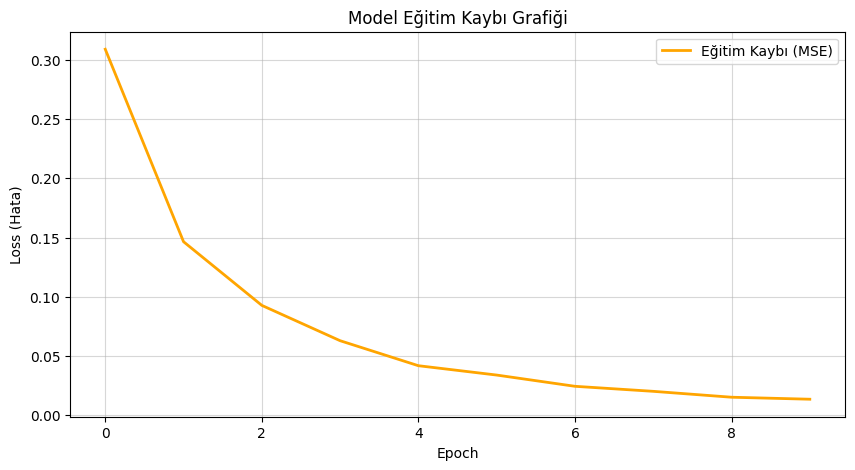

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı (MSE)', color='orange', linewidth=2)
plt.title('Model Eğitim Kaybı Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss (Hata)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### Eğitim Verisi: Gerçek Değerler ve Tahminler


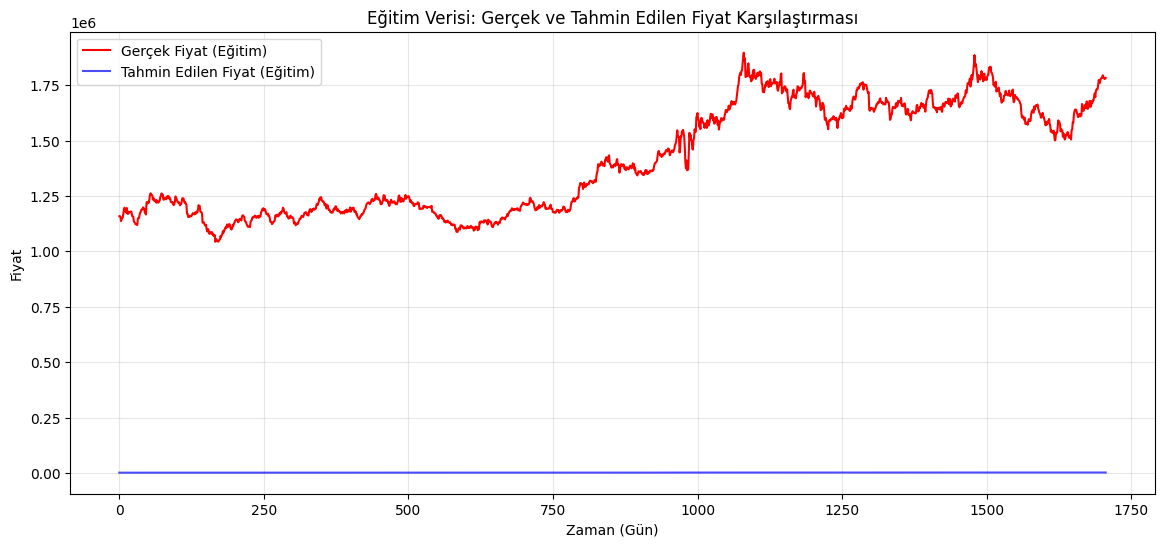

In [37]:
plt.figure(figsize=(14, 6))
plt.plot(y_train, color='red', label='Gerçek Fiyat (Eğitim)', linewidth=1.5)
plt.plot(y_pred, color='blue', label='Tahmin Edilen Fiyat (Eğitim)', alpha=0.7, linewidth=1.5)
plt.title('Eğitim Verisi: Gerçek ve Tahmin Edilen Fiyat Karşılaştırması')
plt.xlabel('Zaman (Gün)')
plt.ylabel('Fiyat')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Doğrulama (Validation) Verisi: Gerçek Değerler ve Tahminler


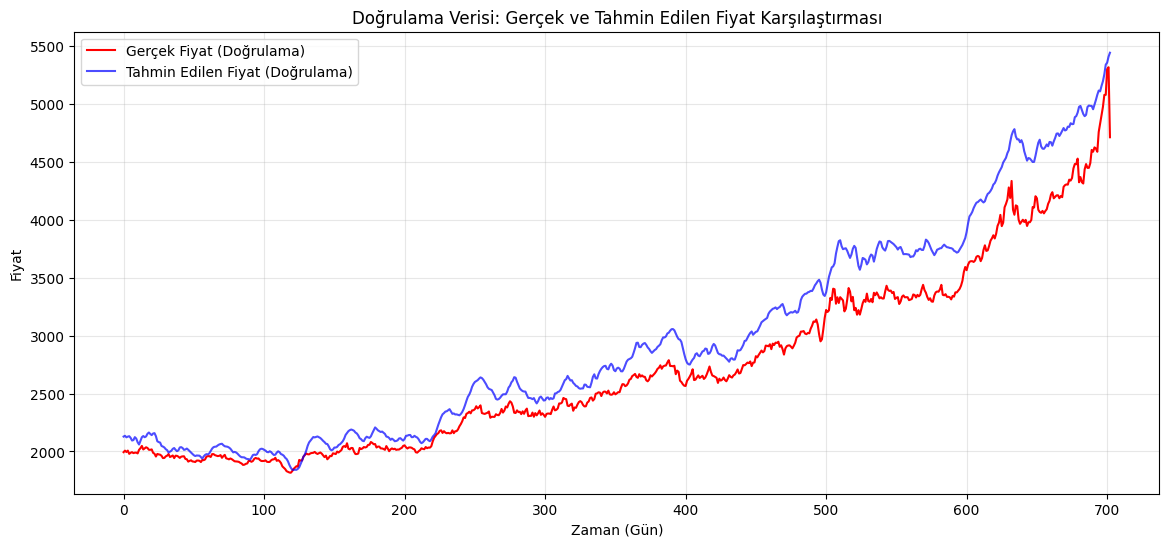

In [38]:
# Tahminleri orijinal ölçeğe (fiyat aralığına) geri döndürüyoruz
y_pred_val_is = scaler.inverse_transform(y_pred_val)

plt.figure(figsize=(14, 6))
plt.plot(y_val_is, color='red', label='Gerçek Fiyat (Doğrulama)', linewidth=1.5)
plt.plot(y_pred_val_is, color='blue', label='Tahmin Edilen Fiyat (Doğrulama)', alpha=0.7, linewidth=1.5)
plt.title('Doğrulama Verisi: Gerçek ve Tahmin Edilen Fiyat Karşılaştırması')
plt.xlabel('Zaman (Gün)')
plt.ylabel('Fiyat')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Tüm Veri Setinin Genel Görünümü

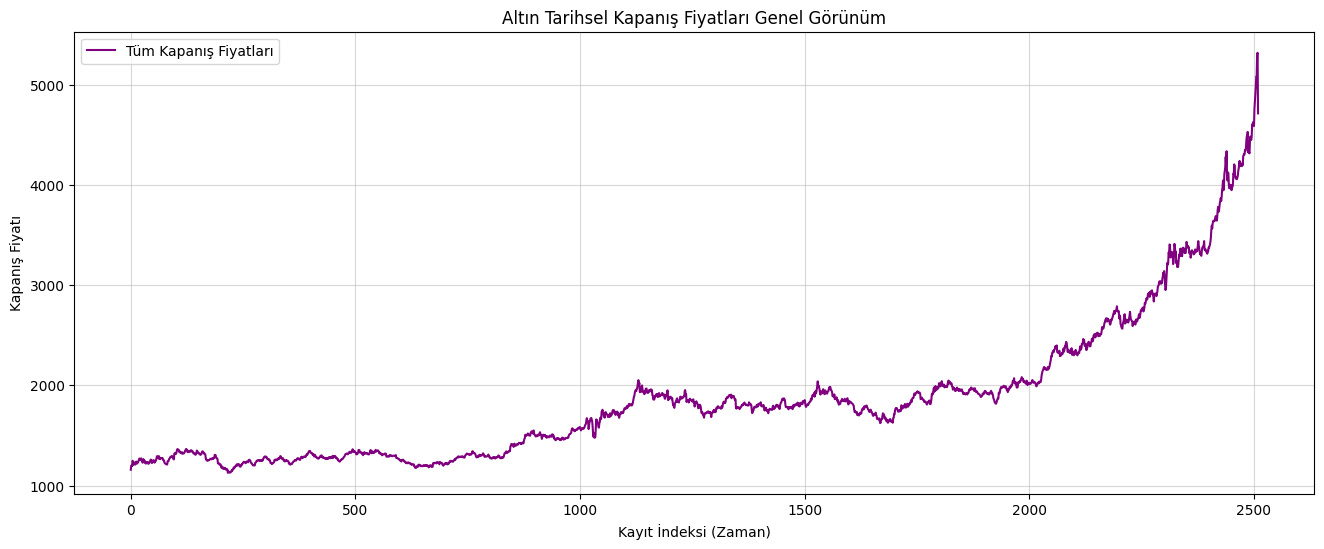

In [39]:
plt.figure(figsize=(16, 6))
plt.plot(df['Close'], color='purple', label='Tüm Kapanış Fiyatları')
plt.title('Altın Tarihsel Kapanış Fiyatları Genel Görünüm')
plt.xlabel('Kayıt İndeksi (Zaman)')
plt.ylabel('Kapanış Fiyatı')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()